In [1]:
# Importando as bibliotecas necessárias
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm

In [ ]:
# # Transformação: converte para tensor e normaliza (média e desvio de MNIST)
# transform = transforms.Compose([
#     transforms.ToTensor(),
#     transforms.Normalize((0.1307,), (0.3081,))
# ])

# # Dataset de treino e teste
# train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
# test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# # Subset com os primeiros 1000 para treino e 500 para validação
# train_subset = Subset(train_dataset, range(1000))
# val_subset   = Subset(test_dataset, range(500))

# # DataLoaders
# train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
# val_loader   = DataLoader(val_subset, batch_size=64, shuffle=False)

In [2]:
# Transformação padrão para Fashion-MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))
])

# Dataset Fashion-MNIST
full_train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
full_val_dataset   = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# Subsets reduzidos
train_subset = Subset(full_train_dataset, range(200))
val_subset   = Subset(full_val_dataset, range(200))

# DataLoaders
train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_subset, batch_size=64, shuffle=False)

100%|██████████| 26.4M/26.4M [00:02<00:00, 8.98MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 132kB/s]
100%|██████████| 4.42M/4.42M [00:02<00:00, 2.18MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.6MB/s]


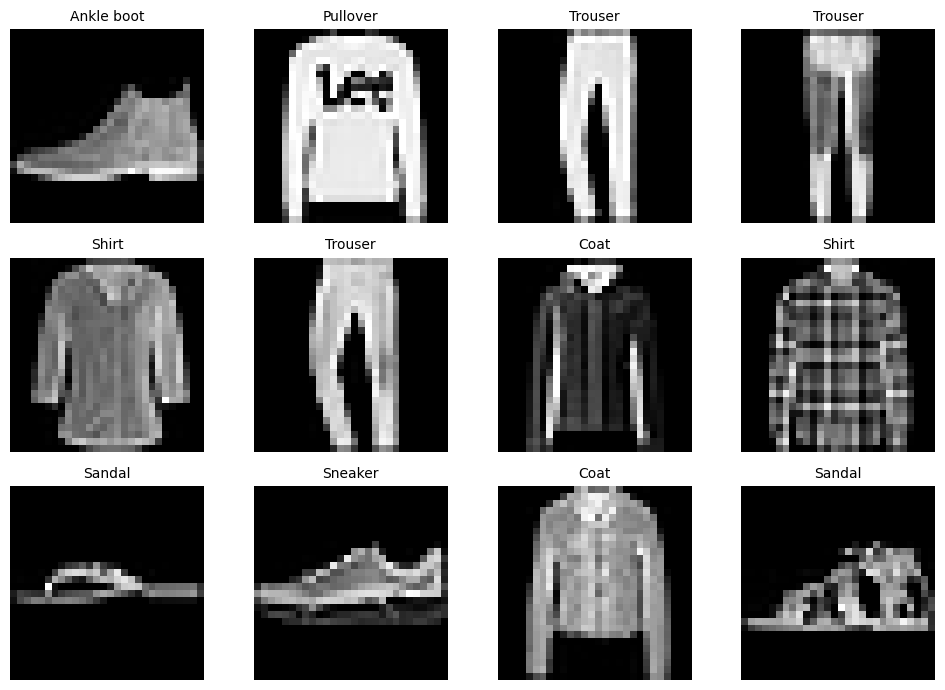

In [3]:
# Classe names
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# Mostrar 12 imagens
fig, axes = plt.subplots(3, 4, figsize=(10, 7))
for i, ax in enumerate(axes.flatten()):
    img, label = val_subset[i]
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(class_names[label], fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [4]:
def train_model(model, trainloader, valloader, criterion, optimizer, num_epochs=5):
    history = {
        'train_losses': [],
        'val_losses': [],
        'train_accuracies': [],
        'val_accuracies': []
    }

    for epoch in range(num_epochs):
        # Treinamento
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        for i, data in tqdm(enumerate(trainloader, 0), total=len(trainloader)):
            inputs, labels = data

            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(trainloader)
        train_acc = 100 * correct / total
        history['train_losses'].append(train_loss)
        history['train_accuracies'].append(train_acc)
        print(f'Epoch {epoch+1}, Train Loss: {train_loss:.3f}, Train Accuracy: {train_acc:.2f}%')

        # Validação
        model.eval()
        val_running_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for data in valloader:
                inputs, labels = data
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_running_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_loss = val_running_loss / len(valloader)
        val_acc = 100 * correct / total
        history['val_losses'].append(val_loss)
        history['val_accuracies'].append(val_acc)
        print(f'Epoch {epoch+1}, Val Loss: {val_loss:.3f}, Val Accuracy: {val_acc:.2f}%')

    print('Treinamento concluído')
    return history


def test_model(model, testloader):
    correct = 0
    total = 0
    with torch.no_grad():
        for data in testloader:
            images, labels = data
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f'Acurácia da rede na base de teste: {100 * correct / total:.2f}%')


def plot_training_history(history):
    epochs = range(1, len(history['train_losses']) + 1)

    plt.figure(figsize=(12, 5))

    # Losses
    plt.subplot(1, 2, 1)
    plt.grid()
    plt.plot(epochs, history['train_losses'], label='Train Loss')
    plt.plot(epochs, history['val_losses'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()

    # Accuracies
    plt.subplot(1, 2, 2)
    plt.grid()
    plt.plot(epochs, history['train_accuracies'], label='Train Accuracy')
    plt.plot(epochs, history['val_accuracies'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

In [5]:
class CNN(nn.Module):
    def __init__(self, initialize_weights=True, dropout=0.2):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, 5)
        self.conv2 = nn.Conv2d(8, 16, 5)
        self.fc1 = nn.Linear(16 * 4 * 4, 64)
        self.fc2 = nn.Linear(64, 10)
        self.dropout = nn.Dropout(dropout)

        if initialize_weights:
            self._initialize_weights()

    def forward(self, x):
        # CNN
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2, 2)

        # Flatten
        x = x.view(-1, 16 * 4 * 4)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)

        return x

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

100%|██████████| 4/4 [00:00<00:00, 13.39it/s]


Epoch 1, Train Loss: 2.309, Train Accuracy: 9.50%
Epoch 1, Val Loss: 2.298, Val Accuracy: 8.50%


100%|██████████| 4/4 [00:00<00:00, 47.80it/s]


Epoch 2, Train Loss: 2.299, Train Accuracy: 9.50%
Epoch 2, Val Loss: 2.286, Val Accuracy: 12.00%


100%|██████████| 4/4 [00:00<00:00, 46.63it/s]


...

Epoch 18, Train Loss: 0.656, Train Accuracy: 72.50%
Epoch 18, Val Loss: 0.948, Val Accuracy: 66.50%


100%|██████████| 4/4 [00:00<00:00, 47.39it/s]


Epoch 19, Train Loss: 0.880, Train Accuracy: 73.50%
Epoch 19, Val Loss: 0.845, Val Accuracy: 67.50%


100%|██████████| 4/4 [00:00<00:00, 48.54it/s]


Epoch 20, Train Loss: 0.947, Train Accuracy: 67.50%
Epoch 20, Val Loss: 0.927, Val Accuracy: 65.50%
Treinamento concluído


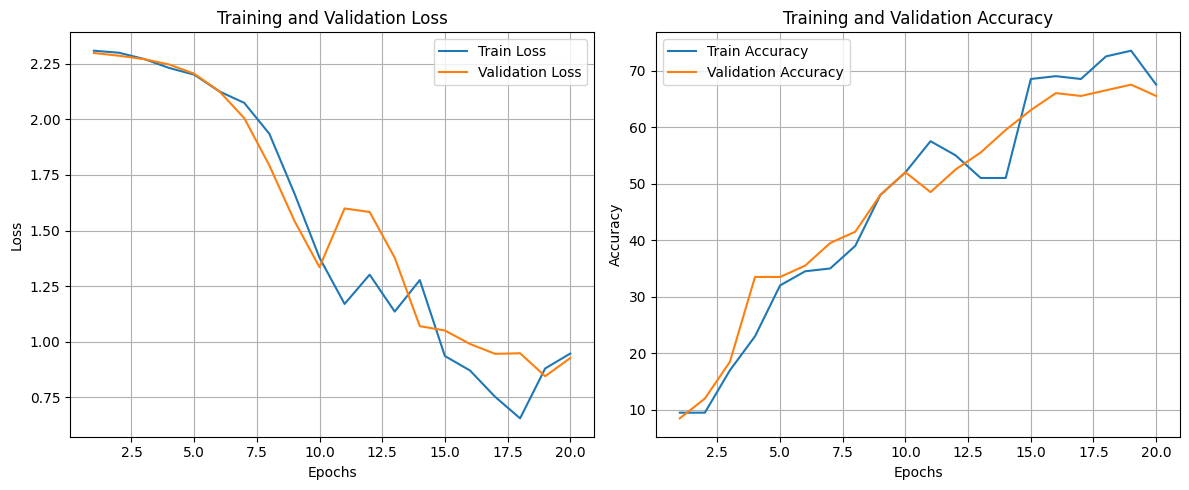

Acurácia da rede na base de teste: 65.50%


In [6]:
model_1 = CNN(
    initialize_weights=False,
    dropout=0.0
)

criterion_1 = nn.CrossEntropyLoss()
optimizer_1 = optim.SGD(model_1.parameters(), lr=0.01, momentum=0.9)

# Treinando a CNN
history_1 = train_model(
    model=model_1,
    trainloader=train_loader,
    valloader=val_loader,
    criterion=criterion_1,
    optimizer=optimizer_1,
    num_epochs=20
)

plot_training_history(history_1)

test_model(model_1, val_loader)

100%|██████████| 4/4 [00:00<00:00, 44.25it/s]


Epoch 1, Train Loss: 2.522, Train Accuracy: 11.00%
Epoch 1, Val Loss: 2.265, Val Accuracy: 16.50%


100%|██████████| 4/4 [00:00<00:00, 47.20it/s]


Epoch 2, Train Loss: 2.251, Train Accuracy: 18.00%
Epoch 2, Val Loss: 2.222, Val Accuracy: 32.00%


100%|██████████| 4/4 [00:00<00:00, 45.03it/s]


...

Epoch 18, Train Loss: 0.779, Train Accuracy: 67.50%
Epoch 18, Val Loss: 0.906, Val Accuracy: 70.00%


100%|██████████| 4/4 [00:00<00:00, 46.64it/s]


Epoch 19, Train Loss: 0.844, Train Accuracy: 72.00%
Epoch 19, Val Loss: 0.927, Val Accuracy: 68.50%


100%|██████████| 4/4 [00:00<00:00, 44.89it/s]


Epoch 20, Train Loss: 0.875, Train Accuracy: 72.00%
Epoch 20, Val Loss: 0.972, Val Accuracy: 66.50%
Treinamento concluído


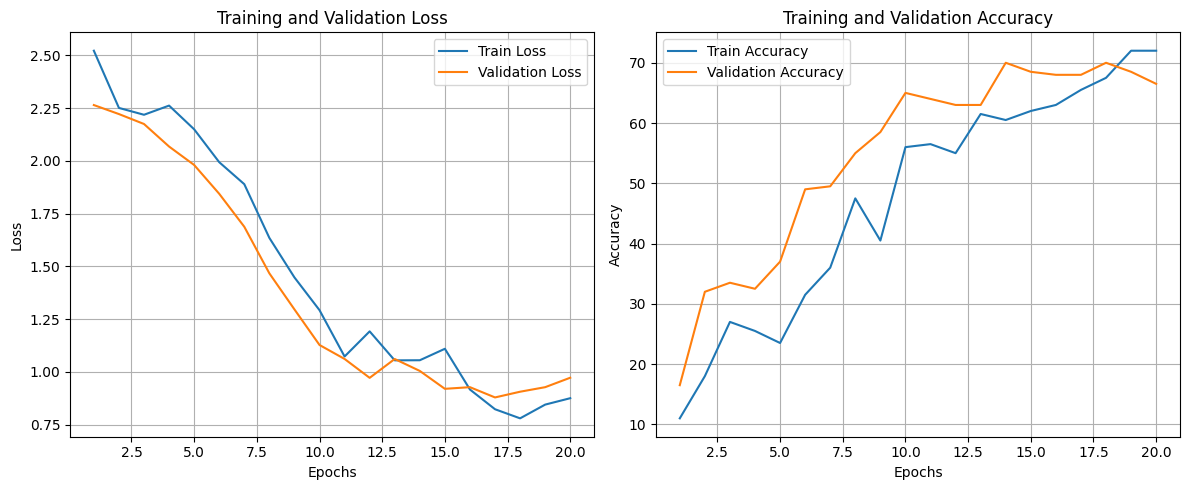

Acurácia da rede na base de teste: 66.50%


In [7]:
model_2 = CNN(
    initialize_weights=True,
    dropout=0.5
)

criterion_2 = nn.CrossEntropyLoss()
optimizer_2 = optim.SGD(model_2.parameters(), lr=0.01, momentum=0.9)

# Treinando a CNN
history_2 = train_model(
    model=model_2,
    trainloader=train_loader,
    valloader=val_loader,
    criterion=criterion_2,
    optimizer=optimizer_2,
    num_epochs=20
)

plot_training_history(history_2)

test_model(model_2, val_loader)

## Exercícios

### Exercício 1
Na CNN implementada, execute experimentos variando:
- O número de filtros convolucionais em `self.conv1` (6 e 8)
- O número de filtros convolucionais em `self.conv2` (12 e 16)

Ao final, observe qual combinação desempenha melhor no conjunto de testes.

Dica: Adicionar argumentos no construtor da classe para determinar o número de filtros em cada camada pode ser útil para inicializar diversos modelos.

In [13]:
class CNN(nn.Module):
    def __init__(self, n_filters1, n_filters2, initialize_weights=True, dropout=0.2):
        super().__init__()

        self.conv1 = nn.Conv2d(1, n_filters1, kernel_size=5)
        self.conv2 = nn.Conv2d(n_filters1, n_filters2, kernel_size=5)
        self.fc1 = nn.Linear(n_filters2 * 4 * 4, 64)
        self.fc2 = nn.Linear(64, 10)
        self.dropout = nn.Dropout(dropout)

        if initialize_weights:
            self._initialize_weights()

    def forward(self, x):
        # CNN
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2, 2)

        # Flatten
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)

        return x

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)


Treinando modelo com conv1=6, conv2=12


100%|██████████| 4/4 [00:00<00:00, 46.64it/s]


Epoch 1, Train Loss: 2.274, Train Accuracy: 12.50%
Epoch 1, Val Loss: 2.187, Val Accuracy: 15.00%


100%|██████████| 4/4 [00:00<00:00, 47.80it/s]


Epoch 2, Train Loss: 2.087, Train Accuracy: 21.00%
Epoch 2, Val Loss: 2.108, Val Accuracy: 22.50%


...

100%|██████████| 4/4 [00:00<00:00, 42.76it/s]


Epoch 19, Train Loss: 0.655, Train Accuracy: 75.00%
Epoch 19, Val Loss: 0.903, Val Accuracy: 68.50%


100%|██████████| 4/4 [00:00<00:00, 29.41it/s]

Epoch 20, Train Loss: 0.701, Train Accuracy: 77.00%


Epoch 20, Val Loss: 0.946, Val Accuracy: 65.50%
Treinamento concluído
Acurácia da rede na base de teste: 65.50%


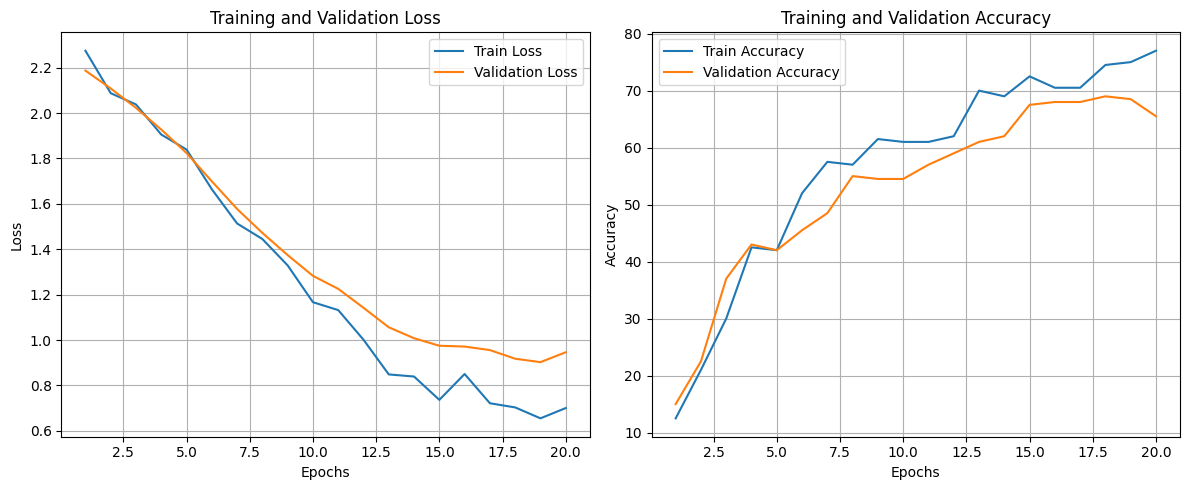


Treinando modelo com conv1=6, conv2=16


100%|██████████| 4/4 [00:00<00:00, 33.26it/s]

Epoch 1, Train Loss: 2.285, Train Accuracy: 13.00%


Epoch 1, Val Loss: 2.184, Val Accuracy: 21.00%


100%|██████████| 4/4 [00:00<00:00, 33.27it/s]

...

Epoch 18, Train Loss: 0.846, Train Accuracy: 69.00%
Epoch 18, Val Loss: 0.977, Val Accuracy: 68.50%


100%|██████████| 4/4 [00:00<00:00, 46.83it/s]


Epoch 19, Train Loss: 0.784, Train Accuracy: 71.50%
Epoch 19, Val Loss: 0.968, Val Accuracy: 64.00%


100%|██████████| 4/4 [00:00<00:00, 45.39it/s]


Epoch 20, Train Loss: 0.835, Train Accuracy: 70.50%
Epoch 20, Val Loss: 0.955, Val Accuracy: 62.50%
Treinamento concluído
Acurácia da rede na base de teste: 62.50%


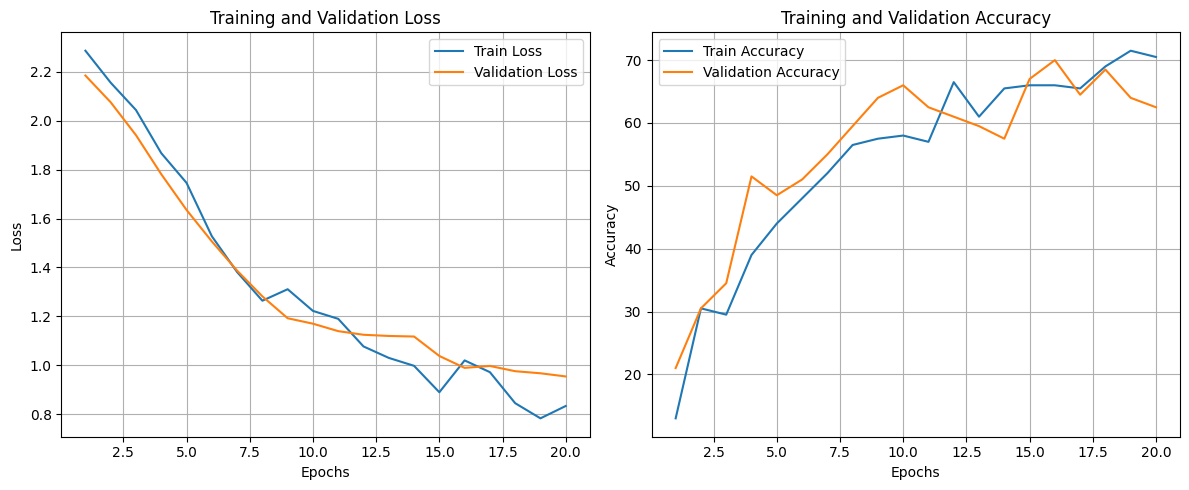


Treinando modelo com conv1=8, conv2=12


100%|██████████| 4/4 [00:00<00:00, 40.63it/s]


Epoch 1, Train Loss: 2.366, Train Accuracy: 15.00%
Epoch 1, Val Loss: 2.159, Val Accuracy: 29.50%


100%|██████████| 4/4 [00:00<00:00, 44.41it/s]


Epoch 2, Train Loss: 2.135, Train Accuracy: 31.00%
Epoch 2, Val Loss: 2.047, Val Accuracy: 32.50%


...

Epoch 18, Train Loss: 0.848, Train Accuracy: 76.00%
Epoch 18, Val Loss: 0.875, Val Accuracy: 68.50%


100%|██████████| 4/4 [00:00<00:00, 36.22it/s]


Epoch 19, Train Loss: 0.649, Train Accuracy: 74.00%
Epoch 19, Val Loss: 0.868, Val Accuracy: 67.50%


100%|██████████| 4/4 [00:00<00:00, 41.65it/s]


Epoch 20, Train Loss: 0.736, Train Accuracy: 75.50%
Epoch 20, Val Loss: 0.869, Val Accuracy: 67.50%
Treinamento concluído
Acurácia da rede na base de teste: 67.50%


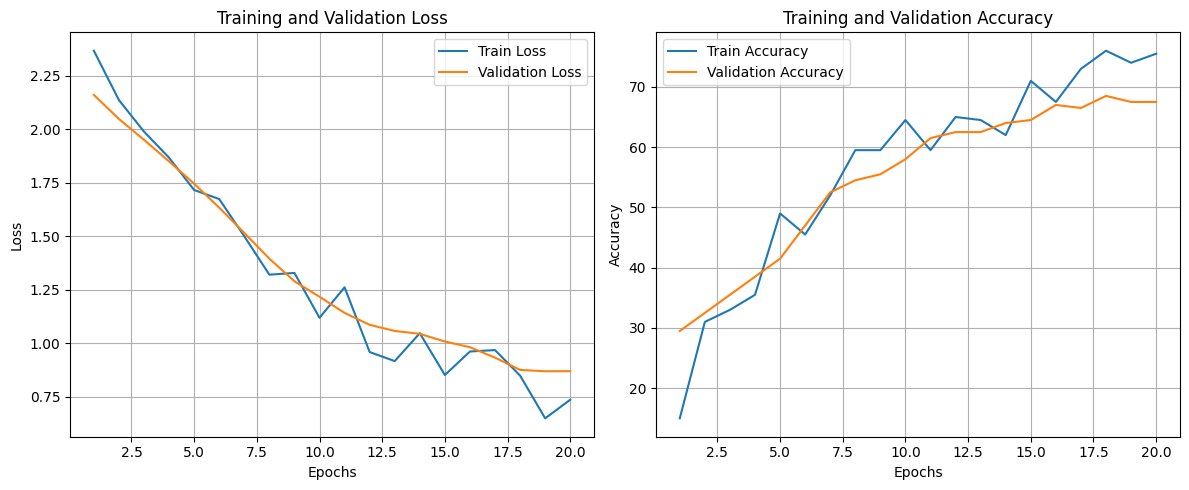


Treinando modelo com conv1=8, conv2=16


100%|██████████| 4/4 [00:00<00:00, 38.84it/s]


Epoch 1, Train Loss: 2.284, Train Accuracy: 15.50%
Epoch 1, Val Loss: 2.132, Val Accuracy: 13.50%


100%|██████████| 4/4 [00:00<00:00, 40.49it/s]


Epoch 2, Train Loss: 2.196, Train Accuracy: 18.00%
Epoch 2, Val Loss: 2.028, Val Accuracy: 21.50%


...

Epoch 18, Train Loss: 0.715, Train Accuracy: 75.50%
Epoch 18, Val Loss: 0.922, Val Accuracy: 70.00%


100%|██████████| 4/4 [00:00<00:00, 41.62it/s]


Epoch 19, Train Loss: 0.726, Train Accuracy: 73.50%
Epoch 19, Val Loss: 0.853, Val Accuracy: 72.00%


100%|██████████| 4/4 [00:00<00:00, 42.19it/s]


Epoch 20, Train Loss: 0.525, Train Accuracy: 78.00%
Epoch 20, Val Loss: 0.817, Val Accuracy: 70.50%
Treinamento concluído
Acurácia da rede na base de teste: 70.50%


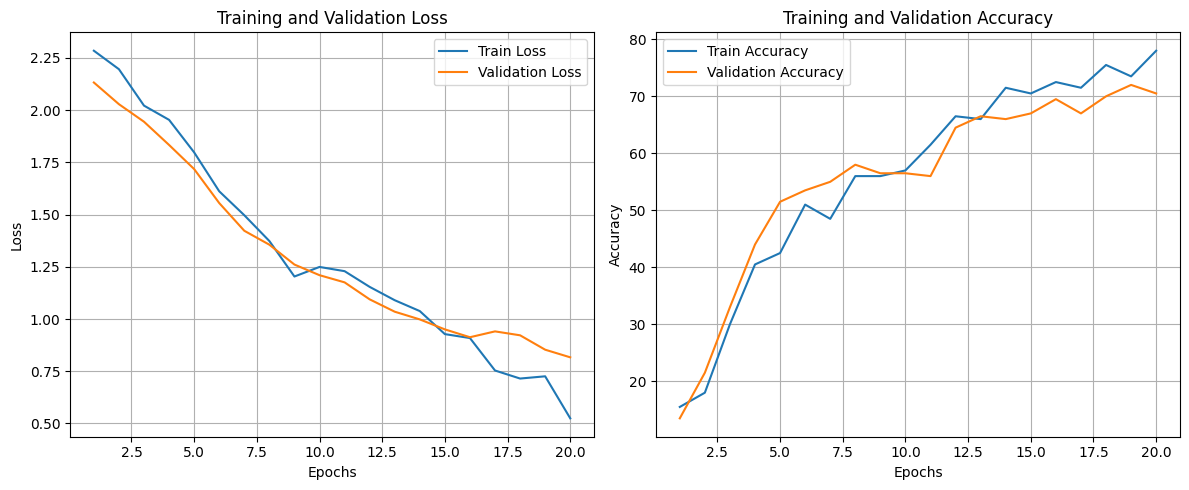

In [14]:
configs = [
    (6, 12),
    (6, 16),
    (8, 12),
    (8, 16)
]

for f1, f2 in configs:
    print(f"\nTreinando modelo com conv1={f1}, conv2={f2}")
    model = CNN(n_filters1=f1, n_filters2=f2)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    history = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=20)
    test_model(model, val_loader)
    plot_training_history(history)

A combinação 8-16 foi melhor porque:

Teve mais capacidade de aprendizado que 6-12 ou 6-16.

Não foi grande demais para causar overfitting no subset.

Aproveitou bem as duas camadas: conv1 detecta padrões básicos, conv2 combina esses padrões em representações mais sofisticadas.

Mais filtros = mais capacidade de extração de padrões, mas com filtros demais pode existir a possibilidade de overfitting.

### Exercício 2

Na CNN implementada, execute 5 treinamentos variando aleatoriamente o número de neurônios de saída em `self.fc1` (o valor atual é 64 e também deve ser alterado na entrada da próxima camada).

Como você determinaria qual foi o melhor valor?

In [ ]:
# for i in range(5):
#     num_neurons = np.random.randint(10, 100)
#     model = ...
#     criterion = ...
#     optimizer = ...
#     history = ...

#     print(f'Número de neurônios na camada fully connected: {num_neurons}')
#     test_model(model, val_loader)
#     print()

In [22]:
class CNN(nn.Module):
    def __init__(self, n_filters1, n_filters2, fc1_neurons, initialize_weights=True, dropout=0.2):
        super().__init__()
        self.conv1 = nn.Conv2d(1, n_filters1, kernel_size=5)
        self.conv2 = nn.Conv2d(n_filters1, n_filters2, kernel_size=5)
        self.fc1 = nn.Linear(n_filters2 * 4 * 4, fc1_neurons)
        self.fc2 = nn.Linear(fc1_neurons, 10)
        self.dropout = nn.Dropout(dropout)

        if initialize_weights:
            self._initialize_weights()

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2, 2)

        x = x.view(-1, self.fc1.in_features)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

In [23]:
results = []

for i in range(5):
    fc1_neurons = np.random.randint(10, 100)
    print(f'Treinamento {i+1} com {fc1_neurons} neurônios na camada fc1')

    model = CNN(n_filters1=8, n_filters2=16, fc1_neurons=fc1_neurons)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    history = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=20)

    acc = history['val_accuracies'][-1]
    print(f"Acurácia de validação final: {acc:.2f}%\n")
    results.append((fc1_neurons, acc))

Treinamento 1 com 56 neurônios na camada fc1


100%|██████████| 4/4 [00:00<00:00, 39.96it/s]


Epoch 1, Train Loss: 2.283, Train Accuracy: 16.50%
Epoch 1, Val Loss: 2.193, Val Accuracy: 21.00%


100%|██████████| 4/4 [00:00<00:00, 43.80it/s]


Epoch 2, Train Loss: 2.125, Train Accuracy: 24.00%
Epoch 2, Val Loss: 2.103, Val Accuracy: 24.00%


...

Epoch 18, Train Loss: 0.848, Train Accuracy: 70.00%
Epoch 18, Val Loss: 1.015, Val Accuracy: 61.50%


100%|██████████| 4/4 [00:00<00:00, 45.07it/s]


Epoch 19, Train Loss: 0.826, Train Accuracy: 68.50%
Epoch 19, Val Loss: 1.006, Val Accuracy: 61.00%


100%|██████████| 4/4 [00:00<00:00, 44.37it/s]


Epoch 20, Train Loss: 0.806, Train Accuracy: 74.00%
Epoch 20, Val Loss: 1.029, Val Accuracy: 65.50%
Treinamento concluído
Acurácia de validação final: 65.50%



In [24]:
melhor = max(results, key=lambda x: x[1])
print(f"Melhor configuração: {melhor[0]} neurônios => {melhor[1]:.2f}% de acurácia na validação")

Melhor configuração: 86 neurônios => 66.50% de acurácia na validação
